# Passos Mágicos: modelo preditivo de risco de defasagem

Construímos um modelo que estima a probabilidade de um aluno entrar em defasagem, ou aprofundar a que já tem, no ano seguinte, a partir dos indicadores do ano atual. A ideia é que, no início de cada ano letivo, a Passos Mágicos aplique o modelo aos indicadores do PEDE mais recente e receba uma lista de alunos em ordem de prioridade para acompanhamento.

Os dados vêm de `dados/tratados/pede_long.csv`, gerado no notebook `01_limpeza`.

## 1. Importação das bibliotecas

In [1]:
%pip install "pandas>=2.2" numpy matplotlib scikit-learn==1.8.0 joblib -q

In [2]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, brier_score_loss,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings("ignore")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
# Mesmas funções usadas pelo app, para que treino e predição calculem as variáveis do mesmo jeito
from src.features import FEATURES, montar_pares, preparar_features

FIGURAS = RAIZ / "figuras"
MODELOS = RAIZ / "modelos"
FIGURAS.mkdir(parents=True, exist_ok=True)
MODELOS.mkdir(parents=True, exist_ok=True)

AZUL, LARANJA, CINZA = "#2a78d6", "#eb6834", "#8a8984"
RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.titleweight": "bold"})

## 2. Carregamento dos dados

In [3]:
df = pd.read_csv(RAIZ / "dados" / "tratados" / "pede_long.csv")
print(f"Shape: {df.shape}")
df.groupby("ano").size()

Shape: (3030, 27)


ano
2022     860
2023    1014
2024    1156
dtype: int64

## 3. Definição do target

Tomamos dois cuidados na definição do alvo.

O primeiro é prever o ano seguinte. O IAN é a defasagem do ano recodificada, o INDE incorpora o IAN e a Pedra deriva do INDE. Um modelo que usasse os indicadores de um ano para prever a defasagem do mesmo ano só estaria relendo a resposta. Por isso usamos os indicadores do ano *t* para prever o que acontece em *t+1*, cruzando o mesmo aluno pelo `ra`.

O segundo é definir o que conta como risco. A defasagem é `fase − fase ideal`, e valores negativos indicam atraso. O target marca o aluno cuja defasagem piora de *t* para *t+1* e que termina *t+1* defasado:

`risco = (defasagem_t+1 < defasagem_t) e (defasagem_t+1 < 0)`

Isso cobre quem entra em defasagem (estava em fase e passa a estar atrasado) e quem aprofunda um atraso que já tinha. Um aluno adiantado que perde parte do adiantamento, mas continua em fase, não conta como risco.

Universitários (fases 8 e 9) ficam de fora, pois não participam do mesmo ciclo de avaliação.

In [4]:
pares = montar_pares(df)
print(f"Pares aluno/ano (t -> t+1): {len(pares)}")
print()
print(pares.groupby("ano")["risco"].agg(["size", "sum", "mean"])
           .rename(columns={"size": "alunos", "sum": "em_risco", "mean": "taxa"})
           .rename(lambda a: f"{a} -> {a + 1}").round(3))

Pares aluno/ano (t -> t+1): 1273

              alunos  em_risco   taxa
ano                                  
2022 -> 2023     581        98  0.169
2023 -> 2024     692       114  0.165


In [5]:
pd.crosstab(pares["defasagem"], pares["defasagem_seguinte"], margins=True)

defasagem_seguinte,-4,-3,-2,-1,0,1,2,All
defasagem,,,,,,,,
-4,1,1,0,0,0,0,0,2
-3,0,3,9,0,0,2,0,14
-2,0,5,76,108,5,0,0,194
-1,0,0,63,264,238,2,3,570
0,0,0,1,142,221,74,11,449
1,0,0,0,1,15,14,6,36
2,0,0,0,0,0,7,1,8
All,1,9,149,515,479,99,21,1273


A taxa de risco é de 17% e praticamente igual nas duas janelas (16,9% e 16,5%), o que dá estabilidade para validar o modelo de um ano para o outro. A tabela cruzada mostra onde o risco se concentra: entre os alunos com defasagem 0 (em fase), muitos passam para −1 no ano seguinte. Boa parte do risco está em alunos que hoje parecem estar bem, como já tinha aparecido na análise de retenção de fase do notebook 02.

## 4. Engenharia de atributos (feature engineering)

Usamos as seguintes variáveis do ano t:

- posição no ciclo: `fase`, `idade`, `defasagem` atual e `anos_programa` (ano − ano de ingresso);
- indicadores: `iaa`, `ieg`, `ips`, `ida` e `ipv`;
- notas de Matemática e Português (`mat` e `por`);
- `gap_autoavaliacao` = IAA − IDA, que criamos para medir o quanto o aluno se avalia acima do próprio desempenho. A análise exploratória mostrou que esse descolamento é grande e varia muito entre alunos.

Ficaram de fora o IAN, que é a defasagem atual recodificada em 3 faixas (a própria `defasagem` já entra com mais detalhe), e o INDE e a Pedra, que são combinação linear fixa dos indicadores (INDE = 0,1·IAN + 0,2·IDA + 0,2·IEG + 0,1·IAA + 0,1·IPS + 0,1·IPP + 0,2·IPV). Eles não trazem informação nova e ainda obrigariam o usuário do app a calcular o INDE. O IPP também ficou fora porque não existe em 2022, o ano de treino da validação temporal, e o Inglês porque falta em cerca de 60% dos registros. Gênero e tipo de escola mostraram diferenças pequenas na análise exploratória, e preferimos não usar atributos demográficos numa ferramenta que prioriza alunos.

Os poucos valores ausentes (até 2%) são imputados pela mediana dentro do pipeline, calculada apenas nos dados de treino.

In [6]:
X_todos = preparar_features(pares)
y_todos = pares["risco"]
print(f"Features: {FEATURES}")
X_todos.describe().T[["mean", "min", "max"]].round(2).assign(ausentes=X_todos.isna().sum())

Features: ['fase', 'idade', 'defasagem', 'anos_programa', 'iaa', 'ieg', 'ips', 'ida', 'ipv', 'mat', 'por', 'gap_autoavaliacao']


,mean,min,max,ausentes
fase,1.89,0.00,7.0,0
idade,11.60,7.00,19.0,0
defasagem,-0.75,-4.00,2.0,0
anos_programa,1.62,0.00,7.0,0
iaa,7.67,0.00,10.0,0
ieg,8.62,2.00,10.0,11
ips,5.94,2.50,10.0,3
ida,6.67,1.00,10.0,11
ipv,7.80,3.32,10.0,11
mat,6.36,0.00,10.0,11


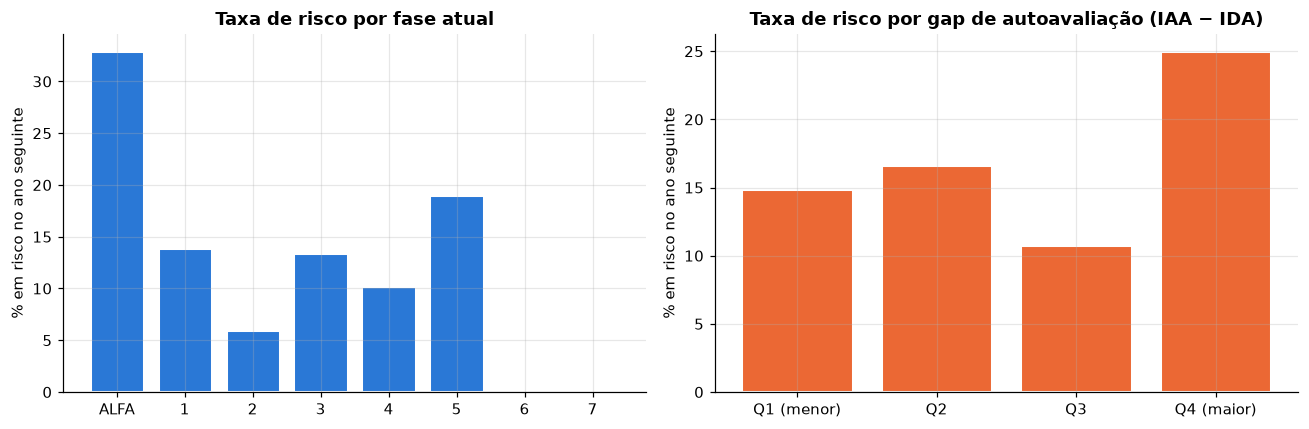

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

taxa_fase = pares.groupby("fase")["risco"].mean() * 100
axes[0].bar(["ALFA"] + [str(f) for f in taxa_fase.index[1:]], taxa_fase.values, color=AZUL, edgecolor="white", linewidth=2)
axes[0].set_title("Taxa de risco por fase atual")
axes[0].set_ylabel("% em risco no ano seguinte")

gap_quartil = pd.qcut(X_todos["gap_autoavaliacao"], 4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"])
taxa_gap = y_todos.groupby(gap_quartil).mean() * 100
axes[1].bar(taxa_gap.index.astype(str), taxa_gap.values, color=LARANJA, edgecolor="white", linewidth=2)
axes[1].set_title("Taxa de risco por gap de autoavaliação (IAA − IDA)")
axes[1].set_ylabel("% em risco no ano seguinte")

plt.tight_layout()
plt.show()

O risco é maior na ALFA (33%) e na fase 5 (19%), justamente as fases de maior retenção. Na fase 7, a última do ciclo, o risco é zero. Em relação ao gap de autoavaliação, a relação não é linear, mas o quartil de alunos que mais se superestimam tem a maior taxa de risco (25%, contra 11% a 17% nos demais).

## 5. Separação dos dados em treino e teste

Em vez de uma divisão aleatória, separamos os dados no tempo. O treino tem os pares 2022-2023 (indicadores de 2022, desfecho observado em 2023), e o teste, os pares 2023-2024.

É o cenário real de uso: o modelo aprende com o passado e é avaliado num ano que não viu. Uma divisão aleatória misturaria os dois anos e daria uma estimativa otimista, porque o mesmo aluno poderia aparecer no treino e no teste.

In [8]:
treino = pares[pares["ano"] == 2022]
teste = pares[pares["ano"] == 2023]

X_train, y_train = preparar_features(treino), treino["risco"]
X_test, y_test = preparar_features(teste), teste["risco"]

print(f"Treino: {len(X_train)} alunos | taxa de risco {y_train.mean():.1%}")
print(f"Teste:  {len(X_test)} alunos | taxa de risco {y_test.mean():.1%}")
print(f"Alunos que aparecem nos dois conjuntos: {treino['ra'].isin(teste['ra']).sum()}")

Treino: 581 alunos | taxa de risco 16.9%
Teste:  692 alunos | taxa de risco 16.5%
Alunos que aparecem nos dois conjuntos: 441


Parte dos alunos aparece nos dois conjuntos, mas em anos diferentes: com os indicadores de 2022 no treino e os de 2023 no teste. Isso reproduz o uso real: o modelo treinado com a história do aluno é aplicado aos seus dados mais recentes.

## 6. Modelagem preditiva

Comparamos sete algoritmos de famílias diferentes e uma regra simples, sempre com validação cruzada estratificada (5 folds) dentro do treino. A regra marca como risco todo aluno em fase (defasagem ≥ 0), o padrão mais evidente na tabela da seção 3. A Regressão Logística é a referência linear e a mais simples de explicar, e a Árvore de Decisão (profundidade 4) gera regras legíveis do tipo "se… então". KNN e SVM classificam o aluno pela semelhança com alunos parecidos, sem supor relação linear. Random Forest, Extra Trees e Gradient Boosting são conjuntos de árvores e capturam interações não lineares, como a combinação de fase e idade.

Onde o algoritmo permite, usamos `class_weight="balanced"`, porque a classe de risco representa apenas 17% dos casos. A métrica principal é a precisão média (AP), que resume a curva precisão × recall e diz mais que a acurácia quando as classes são desbalanceadas. Um modelo aleatório teria AP igual à taxa de risco (~0,17). A escolha usa só o treino; o teste 2023-2024 fica reservado para a seção 7.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def rf_pipeline():
    return make_pipeline(SimpleImputer(strategy="median"),
                         RandomForestClassifier(n_estimators=300, min_samples_leaf=10, class_weight="balanced",
                                                random_state=RANDOM_STATE, n_jobs=-1))

modelos = {
    "Regressão Logística": make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                                         LogisticRegression(max_iter=2000, class_weight="balanced")),
    "Árvore de Decisão": make_pipeline(SimpleImputer(strategy="median"),
                                       DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, class_weight="balanced",
                                                              random_state=RANDOM_STATE)),
    "KNN": make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                         KNeighborsClassifier(n_neighbors=25, weights="distance")),
    "SVM (RBF)": make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                               SVC(class_weight="balanced", probability=True, random_state=RANDOM_STATE)),
    "Random Forest": rf_pipeline(),
    "Extra Trees": make_pipeline(SimpleImputer(strategy="median"),
                                 ExtraTreesClassifier(n_estimators=300, min_samples_leaf=10, class_weight="balanced",
                                                      random_state=RANDOM_STATE, n_jobs=-1)),
    "Gradient Boosting": HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200,
                                                        class_weight="balanced", random_state=RANDOM_STATE),
}

regra_train = (X_train["defasagem"] >= 0).astype(int)
resultados = [{"modelo": "Baseline (em fase = risco)",
               "AUC_cv": roc_auc_score(y_train, regra_train), "AP_cv": average_precision_score(y_train, regra_train)}]
prob_oof = {}
for nome, modelo in modelos.items():
    prob_oof[nome] = cross_val_predict(modelo, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    resultados.append({"modelo": nome,
                       "AUC_cv": roc_auc_score(y_train, prob_oof[nome]),
                       "AP_cv": average_precision_score(y_train, prob_oof[nome])})

pd.DataFrame(resultados).set_index("modelo").sort_values("AUC_cv", ascending=False).round(3)

,AUC_cv,AP_cv
modelo,,
Random Forest,0.848,0.470
Extra Trees,0.846,0.441
Gradient Boosting,0.834,0.474
SVM (RBF),0.819,0.425
Regressão Logística,0.804,0.419
Árvore de Decisão,0.793,0.403
KNN,0.779,0.357
Baseline (em fase = risco),0.676,0.263


Todos os modelos superam a regra simples (AUC 0,676 e AP 0,263). Os três conjuntos de árvores formam o grupo de cima, com AUC entre 0,834 e 0,848. A Regressão Logística fica abaixo (0,804), sinal de que o risco depende de interações entre variáveis que um modelo linear não capta. A Árvore de Decisão isolada seria a mais fácil de explicar, mas perde desempenho (AP 0,403), e o KNN fica por último entre os algoritmos (AP 0,357).

Escolhemos o Random Forest: tem a maior AUC na validação cruzada (0,848), AP praticamente igual à do Gradient Boosting (0,470 contra 0,474), é mais estável com poucos dados (581 alunos no treino) e exige menos ajuste de hiperparâmetros.

### 6.1 Definição do limiar de decisão

O modelo devolve uma probabilidade, e a decisão de acompanhar ou não o aluno depende de um limiar. Para a Passos Mágicos, deixar de identificar um aluno que vai entrar em defasagem custa mais do que acompanhar um aluno que não precisaria. Por isso escolhemos o limiar que garante recall de pelo menos 75% nas previsões fora da amostra do treino. O limiar é definido só com o treino, e o teste permanece intocado.

In [10]:
precisao, recall, limiares = precision_recall_curve(y_train, prob_oof["Random Forest"])
idx = np.where(recall[:-1] >= 0.75)[0].max()
LIMIAR = float(limiares[idx])
print(f"Limiar escolhido: {LIMIAR:.3f}")
print(f"No treino (validação cruzada): recall {recall[idx]:.2f} | precisão {precisao[idx]:.2f}")

Limiar escolhido: 0.465
No treino (validação cruzada): recall 0.76 | precisão 0.47


## 7. Avaliação dos resultados no teste (2023-2024)

In [11]:
modelo_rf = rf_pipeline().fit(X_train, y_train)
prob_test = modelo_rf.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= LIMIAR).astype(int)

print(f"ROC-AUC:           {roc_auc_score(y_test, prob_test):.3f}")
print(f"Precisão média:    {average_precision_score(y_test, prob_test):.3f}  (aleatório = {y_test.mean():.3f})")
print(f"Alunos sinalizados: {pred_test.mean():.0%} da base")
print()
print(classification_report(y_test, pred_test, target_names=["Sem risco", "Em risco"], digits=3))

ROC-AUC:           0.895
Precisão média:    0.666  (aleatório = 0.165)
Alunos sinalizados: 23% da base

              precision    recall  f1-score   support

   Sem risco      0.944     0.874     0.907       578
    Em risco      0.535     0.737     0.620       114

    accuracy                          0.851       692
   macro avg      0.739     0.805     0.764       692
weighted avg      0.877     0.851     0.860       692



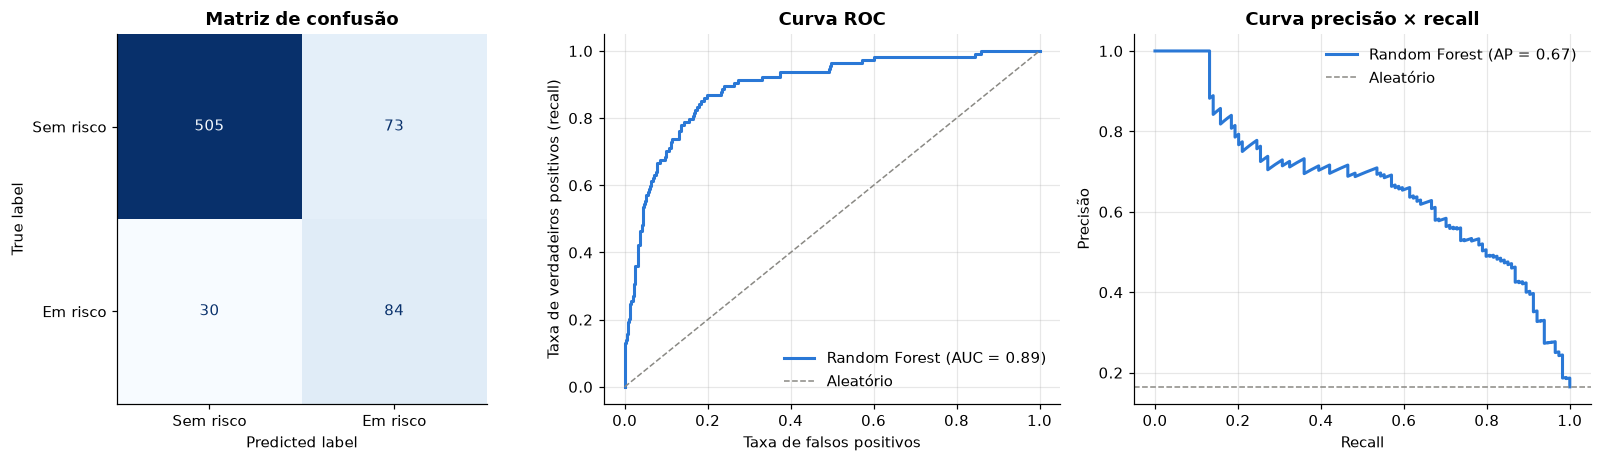

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

cm = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm, display_labels=["Sem risco", "Em risco"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusão")
axes[0].grid(False)

fpr, tpr, _ = roc_curve(y_test, prob_test)
axes[1].plot(fpr, tpr, color=AZUL, linewidth=2, label=f"Random Forest (AUC = {roc_auc_score(y_test, prob_test):.2f})")
axes[1].plot([0, 1], [0, 1], color=CINZA, linestyle="--", linewidth=1, label="Aleatório")
axes[1].set_xlabel("Taxa de falsos positivos")
axes[1].set_ylabel("Taxa de verdadeiros positivos (recall)")
axes[1].set_title("Curva ROC")
axes[1].legend(frameon=False, loc="lower right")

p, r, _ = precision_recall_curve(y_test, prob_test)
axes[2].plot(r, p, color=AZUL, linewidth=2, label=f"Random Forest (AP = {average_precision_score(y_test, prob_test):.2f})")
axes[2].axhline(y_test.mean(), color=CINZA, linestyle="--", linewidth=1, label="Aleatório")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precisão")
axes[2].set_title("Curva precisão × recall")
axes[2].legend(frameon=False)

plt.tight_layout()
plt.savefig(FIGURAS / "modelo_avaliacao.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Visão operacional: quantos casos reais a associação alcança acompanhando os X% de maior risco
ordem = np.argsort(-prob_test)
captura = []
for pct in [0.10, 0.20, 0.30, 0.40]:
    k = int(round(pct * len(prob_test)))
    capturados = y_test.values[ordem[:k]].sum()
    captura.append({"acompanhar top": f"{pct:.0%}", "alunos": k,
                    "casos de risco captados": f"{capturados / y_test.sum():.0%}",
                    "precisão": f"{capturados / k:.0%}"})
pd.DataFrame(captura)

,acompanhar top,alunos,casos de risco captados,precisão
0,10%,69,42%,70%
1,20%,138,70%,58%
2,30%,208,86%,47%
3,40%,277,91%,38%


No ano de teste, que o modelo não viu, a AUC é de 0,89 e a precisão média é de 0,67, cerca de quatro vezes a de uma escolha aleatória (0,16). Com o limiar definido no treino:

- o modelo identifica 74% dos alunos que de fato entraram em defasagem ou a aprofundaram (84 de 114);
- sinaliza 23% dos alunos, e pouco mais da metade deles (54%) realmente entra em risco.

Para a equipe, isso quer dizer que acompanhar os 20% de alunos com maior risco já alcança 70% dos casos, com 58% de acerto. A acurácia geral fica em torno de 85%, mas não é a métrica relevante: um modelo que dissesse "ninguém está em risco" acertaria 84%.

### 7.1 Os outros modelos no ano de teste

Para verificar se a escolha feita no treino se sustenta num ano novo, avaliamos todos os modelos no teste com o mesmo procedimento do Random Forest: cada um recebe o limiar que dá recall de 75% nas suas próprias previsões fora da amostra do treino. O teste não entra em nenhuma decisão, só confere o resultado.

In [14]:
def alcance_top(y, prob, pct=0.20):
    k = int(round(pct * len(prob)))
    return y.values[np.argsort(-prob)[:k]].sum() / y.sum()

prob_teste = {}
comparacao_teste = []
for nome, modelo in modelos.items():
    p, r, t = precision_recall_curve(y_train, prob_oof[nome])
    limiar = t[np.where(r[:-1] >= 0.75)[0].max()]
    prob_teste[nome] = modelo.fit(X_train, y_train).predict_proba(X_test)[:, 1]
    pred = prob_teste[nome] >= limiar
    comparacao_teste.append({"modelo": nome,
                             "AUC_teste": roc_auc_score(y_test, prob_teste[nome]),
                             "AP_teste": average_precision_score(y_test, prob_teste[nome]),
                             "recall": pred[y_test.values == 1].mean(),
                             "precisão": y_test.values[pred].mean(),
                             "sinalizados": pred.mean(),
                             "alcance_top20": alcance_top(y_test, prob_teste[nome])})

comparacao_teste = pd.DataFrame(comparacao_teste).set_index("modelo").sort_values("AP_teste", ascending=False)
comparacao_teste.round(3)

,AUC_teste,AP_teste,recall,precisão,sinalizados,alcance_top20
modelo,,,,,,
Extra Trees,0.896,0.681,0.763,0.551,0.228,0.702
Random Forest,0.895,0.666,0.737,0.535,0.227,0.702
SVM (RBF),0.836,0.623,0.596,0.567,0.173,0.623
KNN,0.845,0.611,0.702,0.419,0.276,0.614
Gradient Boosting,0.888,0.610,0.763,0.506,0.249,0.719
Regressão Logística,0.807,0.494,0.588,0.450,0.215,0.561
Árvore de Decisão,0.681,0.387,0.640,0.311,0.340,0.482


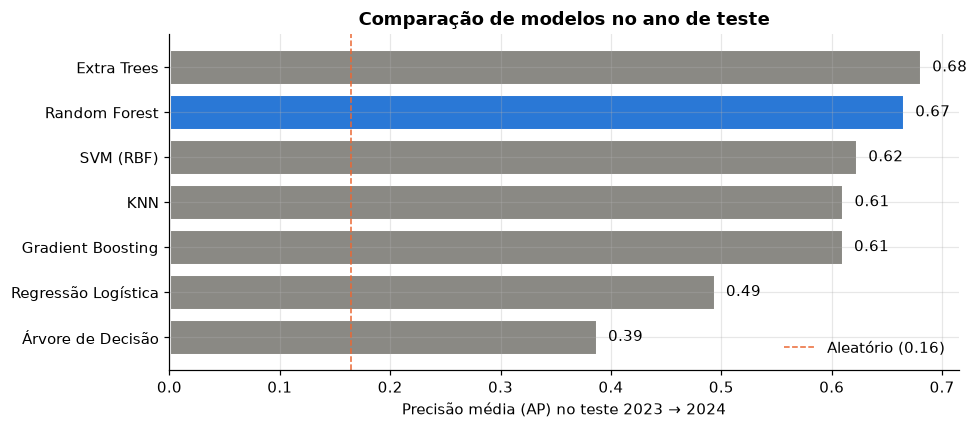

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
ordem_ap = comparacao_teste["AP_teste"].sort_values()
ax.barh(ordem_ap.index, ordem_ap.values, color=[AZUL if n == "Random Forest" else CINZA for n in ordem_ap.index],
        edgecolor="white", linewidth=2)
ax.axvline(y_test.mean(), color=LARANJA, linestyle="--", linewidth=1, label=f"Aleatório ({y_test.mean():.2f})")
for i, v in enumerate(ordem_ap.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center")
ax.set_xlabel("Precisão média (AP) no teste 2023 → 2024")
ax.set_title("Comparação de modelos no ano de teste")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig(FIGURAS / "modelo_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Intervalo de confiança por bootstrap: reamostramos os alunos do teste 2.000 vezes
rng = np.random.default_rng(RANDOM_STATE)
y_arr = y_test.values
amostras = []
for _ in range(2000):
    i = rng.integers(0, len(y_arr), len(y_arr))
    linha = {"AUC do Random Forest": roc_auc_score(y_arr[i], prob_test[i]),
             "AP do Random Forest": average_precision_score(y_arr[i], prob_test[i])}
    for outro in ["Gradient Boosting", "Extra Trees", "Regressão Logística"]:
        linha[f"AUC: RF − {outro}"] = roc_auc_score(y_arr[i], prob_test[i]) - roc_auc_score(y_arr[i], prob_teste[outro][i])
    amostras.append(linha)

amostras = pd.DataFrame(amostras)
amostras.quantile([0.025, 0.975]).T.rename(columns={0.025: "IC 2,5%", 0.975: "IC 97,5%"}).round(3)

,"IC 2,5%","IC 97,5%"
AUC do Random Forest,0.861,0.925
AP do Random Forest,0.578,0.748
AUC: RF − Gradient Boosting,-0.009,0.023
AUC: RF − Extra Trees,-0.012,0.010
AUC: RF − Regressão Logística,0.057,0.119


O ano de teste confirma o que a validação cruzada mostrou. Os três conjuntos de árvores continuam no topo: Extra Trees (AUC 0,896 e AP 0,681), Random Forest (0,895 e 0,666) e Gradient Boosting (0,888 e 0,610). Os intervalos de confiança por bootstrap mostram que as diferenças entre eles não se distinguem do acaso: a diferença de AUC entre Random Forest e Extra Trees vai de −0,012 a +0,010, e entre Random Forest e Gradient Boosting, de −0,009 a +0,023. Já a vantagem sobre a Regressão Logística é consistente (de +0,057 a +0,119).

O Extra Trees ficou ligeiramente à frente no teste, mas trocar de modelo por causa disso seria escolher olhando o teste, e a estimativa de desempenho ficaria otimista. Por isso mantemos o Random Forest escolhido no treino. Para a equipe, os três conjuntos de árvores alcançam entre 70% e 72% dos casos acompanhando os 20% de maior risco. Com 95% de confiança, a AUC do Random Forest no teste fica entre 0,86 e 0,93, e a AP entre 0,58 e 0,75.

### 7.2 Onde o modelo acerta e onde erra

A métrica geral pode esconder diferenças entre grupos. Abrimos o resultado do teste por fase e pela situação atual do aluno (em fase ou já defasado).

In [17]:
aval = teste.assign(prob=prob_test, sinalizado=pred_test.astype(bool), risco=y_test.astype(bool))

def resumo(d):
    casos, sinal = d["risco"].sum(), d["sinalizado"].sum()
    acertos = (d["sinalizado"] & d["risco"]).sum()
    return pd.Series({"alunos": len(d), "casos": casos, "taxa de risco": d["risco"].mean(),
                      "sinalizados": d["sinalizado"].mean(),
                      "recall": acertos / casos if casos else np.nan,
                      "precisão": acertos / sinal if sinal else np.nan})

aval.groupby("fase").apply(resumo).rename(index={0: "ALFA"}).round(2)

,alunos,casos,taxa de risco,sinalizados,recall,precisão
fase,,,,,,
ALFA,174.0,65.0,0.37,0.60,0.92,0.57
1,138.0,21.0,0.15,0.19,0.67,0.54
2,153.0,3.0,0.02,0.03,0.00,0.00
3,94.0,11.0,0.12,0.12,0.45,0.45
4,67.0,4.0,0.06,0.04,0.25,0.33
5,41.0,10.0,0.24,0.17,0.40,0.57
6,14.0,0.0,0.00,0.00,NaN,NaN
7,11.0,0.0,0.00,0.00,NaN,NaN


In [18]:
aval.groupby(np.where(aval["defasagem"] >= 0, "Em fase", "Já defasado")).apply(resumo).round(2)

,alunos,casos,taxa de risco,sinalizados,recall,precisão
Em fase,307.0,84.0,0.27,0.40,0.86,0.59
Já defasado,385.0,30.0,0.08,0.09,0.40,0.35


O modelo é mais forte onde o risco se concentra. Na ALFA, que reúne 65 dos 114 casos do teste, ele identifica 92% dos alunos em risco. Nas fases 3 a 5, identifica 10 dos 25 casos (40%). Nas fases 2, 6 e 7 quase não há casos (3 no total).

A divisão pela situação atual mostra o mesmo padrão. Entre os alunos em fase, o modelo encontra 86% dos que vão entrar em defasagem. Entre os já defasados, que aprofundam o atraso com menos frequência (8%), encontra 40%.

A lista é mais confiável, portanto, para antecipar a entrada na defasagem, principalmente na ALFA. Nas fases 3 a 5, ela precisa ser complementada pelo olhar da equipe pedagógica.

### 7.3 Calibração: a probabilidade pode ser lida ao pé da letra?

Comparamos a probabilidade média prevista com a taxa de risco observada em faixas de probabilidade.

In [19]:
faixas = pd.cut(aval["prob"], [0, 0.2, 0.4, LIMIAR, 0.6, 0.8, 1.0])
calibracao = aval.groupby(faixas, observed=True).agg(alunos=("risco", "size"), prob_media=("prob", "mean"),
                                                     taxa_observada=("risco", "mean"))
referencia = brier_score_loss(y_test, np.full(len(y_test), y_test.mean()))
print(f"Brier score: {brier_score_loss(y_test, prob_test):.3f} (modelo que sempre prevê a taxa média: {referencia:.3f})")
calibracao.round(2)

Brier score: 0.104 (modelo que sempre prevê a taxa média: 0.138)


,alunos,prob_media,taxa_observada
prob,,,
"(0.0, 0.2]",327,0.10,0.02
"(0.2, 0.4]",168,0.28,0.07
"(0.4, 0.465]",40,0.43,0.28
"(0.465, 0.6]",88,0.53,0.41
"(0.6, 0.8]",64,0.67,0.67
"(0.8, 1.0]",5,0.82,1.00


A probabilidade ordena bem os alunos, mas não deve ser lida ao pé da letra abaixo de 0,6. Na faixa de 0,2 a 0,4, o modelo prevê em média 28% e a taxa observada é de 7%; logo acima do limiar (0,465 a 0,6), prevê 53% e observa 41%. É o efeito esperado do `class_weight="balanced"`, que dá mais peso à classe de risco no treino e desloca as probabilidades para cima. A partir de 0,6, previsto e observado coincidem (67% e 67%). O Brier score de 0,104, contra 0,138 de um modelo que prevê sempre a taxa média, confirma que a probabilidade carrega informação real.

Como o uso é priorizar (ordenar a lista e cortar pela capacidade da equipe), a calibração não muda a decisão. No app, deixamos claro que a probabilidade serve para ordenar os alunos.

## 8. Interpretação

Usamos importância por permutação no conjunto de teste: quanto a AUC cai quando os valores de uma variável são embaralhados. Diferente da importância nativa do Random Forest, ela não favorece variáveis com muitos valores distintos.

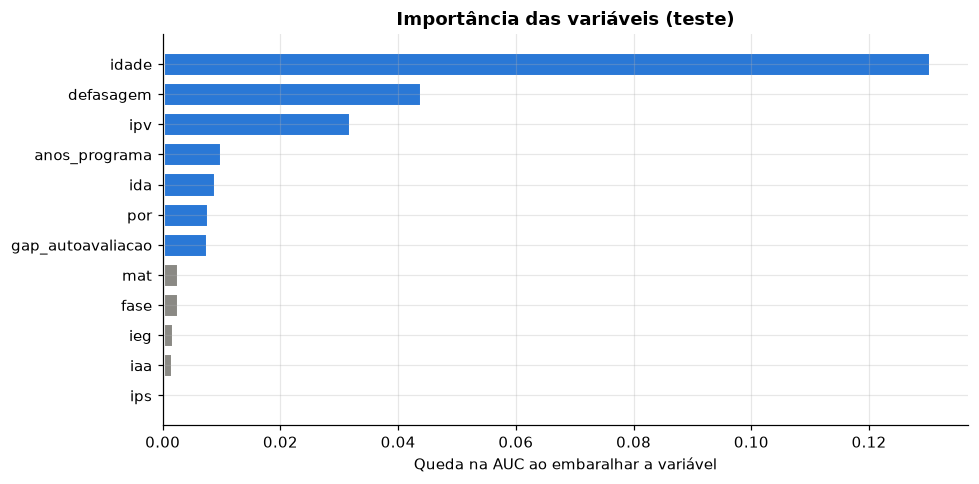

idade                0.130
defasagem            0.044
ipv                  0.032
anos_programa        0.010
ida                  0.009
por                  0.008
gap_autoavaliacao    0.008
mat                  0.003
fase                 0.003
ieg                  0.002
iaa                  0.002
ips                  0.000
dtype: float64

In [20]:
perm = permutation_importance(modelo_rf, X_test, y_test, scoring="roc_auc", n_repeats=30, random_state=RANDOM_STATE)
importancia = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(importancia.index, importancia.values, color=[AZUL if v > 0.005 else CINZA for v in importancia.values],
        edgecolor="white", linewidth=2)
ax.set_xlabel("Queda na AUC ao embaralhar a variável")
ax.set_title("Importância das variáveis (teste)")
plt.tight_layout()
plt.savefig(FIGURAS / "modelo_importancia.png", dpi=150, bbox_inches="tight")
plt.show()

importancia.sort_values(ascending=False).round(3)

In [21]:
# Contexto x indicadores: quanto os indicadores acrescentam à posição do aluno no ciclo
CONTEXTO = ["fase", "idade", "defasagem", "anos_programa"]
comparacao = []
for nome, cols in [("Só posição no ciclo", CONTEXTO), ("Só indicadores e notas", [f for f in FEATURES if f not in CONTEXTO]),
                   ("Modelo completo", FEATURES)]:
    m = make_pipeline(SimpleImputer(strategy="median"),
                      RandomForestClassifier(n_estimators=300, min_samples_leaf=10, class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=-1)).fit(X_train[cols], y_train)
    prob = m.predict_proba(X_test[cols])[:, 1]
    comparacao.append({"variáveis": nome, "AUC": roc_auc_score(y_test, prob), "AP": average_precision_score(y_test, prob)})
pd.DataFrame(comparacao).set_index("variáveis").round(3)

,AUC,AP
variáveis,,
Só posição no ciclo,0.837,0.521
Só indicadores e notas,0.621,0.266
Modelo completo,0.895,0.666


A idade e a defasagem atual são as variáveis mais importantes: juntas, dizem em que ponto do ciclo o aluno está e se a próxima transição de fase é crítica. Em seguida vêm o IPV, o tempo de programa, o IDA, a nota de Português e o gap de autoavaliação.

A comparação mostra o papel de cada grupo. A posição no ciclo sozinha já ordena bem os alunos (AUC 0,84), mas os indicadores elevam a precisão média de 0,52 para 0,67. Os indicadores ajudam a diferenciar, entre dois alunos da mesma idade e fase, qual tem mais chance de ficar retido.

Limitações do modelo:

- O modelo foi treinado com uma única transição de ano (2022-2023) e testado em outra. Com mais anos de histórico, a estimativa fica mais confiável.
- O desempenho não é uniforme entre fases: o recall é de 92% na ALFA e de 40% nas fases 3 a 5 (seção 7.2).
- A probabilidade superestima o risco abaixo de 0,6 (seção 7.3). Serve para ordenar os alunos.
- O IPP ficou de fora por não existir em 2022. Com dados de 2025, vale retreinar incluindo-o, já que ele tem correlação alta com o IPV.
- Alunos que saem do programa não têm desfecho observado e não entram no treino. O modelo estima o risco de quem continua.

## 9. Modelo final e exportação

Para uso no app, o modelo é retreinado com todos os pares disponíveis (2022-2023 e 2023-2024), mantendo os hiperparâmetros e o limiar definidos acima. As métricas registradas continuam sendo as do teste temporal, porque são elas que estimam o desempenho em um ano novo.

In [22]:
modelo_final = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestClassifier(n_estimators=300, min_samples_leaf=10, class_weight="balanced",
                           random_state=RANDOM_STATE, n_jobs=-1),
).fit(X_todos, y_todos)

info = {
    "modelo": "Random Forest (300 árvores, min_samples_leaf=10, class_weight=balanced)",
    "target": "Defasagem piora de t para t+1 e o aluno termina t+1 defasado",
    "features": FEATURES,
    "limiar": round(LIMIAR, 4),
    "treinado_com": f"{len(X_todos)} pares aluno/ano (2022->2023 e 2023->2024)",
    "metricas_teste_2023_2024": {
        "roc_auc": round(roc_auc_score(y_test, prob_test), 4),
        "precisao_media": round(average_precision_score(y_test, prob_test), 4),
        "recall": round(cm[1, 1] / cm[1].sum(), 4),
        "precisao": round(cm[1, 1] / cm[:, 1].sum(), 4),
        "pct_sinalizados": round(pred_test.mean(), 4),
        "taxa_base": round(y_test.mean(), 4),
    },
    "importancia_permutacao": importancia.sort_values(ascending=False).round(4).to_dict(),
    "comparacao_modelos": (pd.DataFrame(resultados).set_index("modelo")
                           .join(comparacao_teste[["AUC_teste", "AP_teste"]]).dropna()
                           .round(4).to_dict("index")),
    "sklearn": sklearn.__version__,
}

joblib.dump(modelo_final, MODELOS / "modelo_risco.joblib")
with open(MODELOS / "modelo_info.json", "w", encoding="utf-8") as f:
    json.dump(info, f, indent=2, ensure_ascii=False)

print(json.dumps(info["metricas_teste_2023_2024"], indent=2))

{
  "roc_auc": 0.8947,
  "precisao_media": 0.6657,
  "recall": 0.7368,
  "precisao": 0.535,
  "pct_sinalizados": 0.2269,
  "taxa_base": 0.1647
}


In [23]:
# Aplicação ao ano mais recente: indicadores de 2024 -> risco estimado para 2025
base_2024 = df[(df["ano"] == 2024) & ~df["flag_universitario"]].copy()
base_2024["prob_risco"] = modelo_final.predict_proba(preparar_features(base_2024))[:, 1]
base_2024["em_risco"] = base_2024["prob_risco"] >= LIMIAR

print(f"Alunos avaliados: {len(base_2024)}")
print(f"Sinalizados para acompanhamento em 2025: {base_2024['em_risco'].sum()} ({base_2024['em_risco'].mean():.0%})")
print()
print(base_2024.groupby("fase")["em_risco"].agg(["sum", "mean"]).rename(columns={"sum": "sinalizados", "mean": "taxa"}).round(2))

Alunos avaliados: 1054
Sinalizados para acompanhamento em 2025: 377 (36%)

      sinalizados  taxa
fase                   
0             142  0.72
1              43  0.23
2              39  0.21
3              98  0.46
4              22  0.19
5              21  0.21
6               3  0.12
7               9  0.24


Aplicado aos indicadores de 2024, o modelo sinaliza 36% dos alunos para acompanhamento em 2025, proporção maior que a do ano de teste (23%). A diferença se concentra na ALFA, historicamente a fase de maior retenção, onde 72% dos alunos são sinalizados. Parte dessa diferença pode vir de mudanças no perfil da turma de 2024 que o modelo ainda não viu, e só será confirmada com os dados de 2025. Por isso sugerimos usar a lista como ranking: a associação acompanha os alunos de maior probabilidade até o limite da sua capacidade de atendimento.

## Conclusão

O modelo final usa 1.273 pares de anos consecutivos do mesmo aluno, das fases 0 a 7, montados a partir da base PEDE de 2022 a 2024. O alvo é o aluno entrar em defasagem ou aprofundar a que já tinha no ano seguinte, o que acontece em 17% dos casos. As variáveis são a posição no ciclo (fase, idade, defasagem atual e anos de programa), os indicadores IAA, IEG, IPS, IDA e IPV, as notas de Matemática e Português e o gap de autoavaliação. Excluímos IAN, INDE e Pedra por serem recodificações da defasagem ou combinações fixas dos indicadores.

A validação é temporal, com treino em 2022-2023 e teste em 2023-2024. Entre sete algoritmos, a validação cruzada do treino apontou o Random Forest com classes balanceadas, e o limiar foi escolhido para recall de 75%. No teste, os três conjuntos de árvores empataram dentro do intervalo de confiança, e todos ficaram bem acima da Regressão Logística e da Árvore de Decisão.

No ano de teste, o modelo teve AUC de 0,89 (IC 95%: 0,86 a 0,93) e precisão média de 0,67, contra 0,16 de uma escolha aleatória. Ele identifica 3 em cada 4 alunos que entram em risco, sinalizando cerca de 1 em cada 4 alunos, e acerta mais na ALFA (92% dos casos) do que nas fases 3 a 5 (40%).

Um modelo que prevê a defasagem do mesmo ano com IAN, INDE ou Pedra chega perto de 100% de acerto sem ter utilidade, porque só relê a resposta. Prevendo o ano seguinte, o modelo responde à pergunta da associação: quem acompanhar agora para evitar a defasagem no próximo ano. O app Streamlit usa o modelo salvo em `modelos/modelo_risco.joblib`.